Requested Citation Acknowledgment:
IEEE OTCBVS WS Series Bench; J. Davis and M. Keck, "A two-stage approach to person detection in thermal imagery," In Proc. Workshop on Applications of Computer Vision, January 2005

# Imports

In [ ]:
### Object Detection with Faster R-CNN and RetinaNet in PyTorch

import re, random, time
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


import torch
from torch.utils.data import Dataset, DataLoader
import pycocotools
import sys

import torchvision
from torchvision.transforms import functional as TF
from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection import retinanet_resnet50_fpn_v2
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchmetrics.detection.mean_ap import MeanAveragePrecision

import os, json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Data Preprocessing and creating data Loaders

In [10]:
def collate_fn(batch):
    return tuple(zip(*batch))

def to_tensor_transform(img):
    # detection models expect float tensor [0..1]
    return torchvision.transforms.ToTensor()(img)
from urllib.parse import unquote, urlparse, parse_qs
def _normalize_ls_filename(file_name: str) -> str:
    """
    Label Studio local-files COCO export often uses paths like:
    'data/local-files/?d=.../my_dataset/images/0001.jpg'
    This returns '0001.jpg'
    """
    if not file_name:
        return ""

    s = str(file_name).replace("\\", "/")

    if "?" in s:
        try:
            parsed = urlparse(s)
            qs = parse_qs(parsed.query)
            if "d" in qs and len(qs["d"]) > 0:
                s = qs["d"][0]  # path inside ?d=
            else:
                # fallback: strip query
                s = s.split("?", 1)[0]
        except Exception:
            s = s.split("?", 1)[0]

    # URL decode (spaces etc.)
    s = unquote(s)

    # Take basename
    s = s.replace("\\", "/")
    return s.split("/")[-1].strip()


class COCODetectionFromLabelStudio(Dataset):
    
    def __init__(self, coco_json_path: str, images_dir: str, transforms=None, category_name="horse"):
        self.coco_json_path = Path(coco_json_path)
        self.images_dir = Path(images_dir)
        self.transforms = transforms

        with open(self.coco_json_path, "r", encoding="utf-8") as f:
            coco = json.load(f)

        # Find category id for "horse"
        cats = coco.get("categories", [])
        name_to_id = {c["name"]: c["id"] for c in cats}
        if category_name not in name_to_id:
            raise ValueError(f"Category '{category_name}' not found in categories: {list(name_to_id.keys())}")
        self.cat_id = name_to_id[category_name]

        # Image records
        self.images = coco.get("images", [])
        # Map image_id -> list of its annotations (filtered to horse)
        anns = coco.get("annotations", [])
        self.ann_by_img = {}
        for a in anns:
            if a.get("category_id") != self.cat_id:
                continue
            img_id = a["image_id"]
            self.ann_by_img.setdefault(img_id, []).append(a)

        # Build list of usable items
        self.items = []
        missing = 0
        for im in self.images:
            img_id = im["id"]
            fn = _normalize_ls_filename(im.get("file_name", ""))
            img_path = self.images_dir / fn
            if not img_path.exists():
                # If filenames don’t match exactly, count > 0
                missing += 1
            self.items.append((img_id, fn))

        print(f"COCO images in JSON: {len(self.items)}")
        print(f"Missing files in images_dir: {missing}.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_id, fn = self.items[idx]
        img_path = self.images_dir / fn
        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")

        anns = self.ann_by_img.get(img_id, [])
        boxes = []
        labels = []

        for a in anns:
            x, y, w, h = a["bbox"]  # COCO format
            x1, y1, x2, y2 = x, y, x + w, y + h
            if x2 <= x1 or y2 <= y1:
                continue
            boxes.append([x1, y1, x2, y2])
            labels.append(1)  # horse = 1 (background = 0)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }
        if boxes.numel() > 0:
            target["area"] = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        else:
            target["area"] = torch.zeros((0,), dtype=torch.float32)

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target


In [ ]:
COCO_JSON  = "dataset/result.json"      # update to your local path
IMAGES_DIR = "dataset/images/"          # update to your local path

dataset = COCODetectionFromLabelStudio(COCO_JSON, IMAGES_DIR, transforms=to_tensor_transform, category_name="horse")

# split 
seed = 42
idxs = list(range(len(dataset)))
random.Random(seed).shuffle(idxs)
train_size = max(1, int(0.8 * len(dataset)))
train_idx = idxs[:train_size]
test_idx = idxs[train_size:]

train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset  = torch.utils.data.Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_fn)

num_classes = 2  # background + horse
print("Train:", len(train_dataset), "Test:", len(test_dataset), "num_classes:", num_classes)

COCO images in JSON: 200
Missing files in images_dir: 0.
Train: 160 Test: 40 num_classes: 2


# Two samples of the Training Data

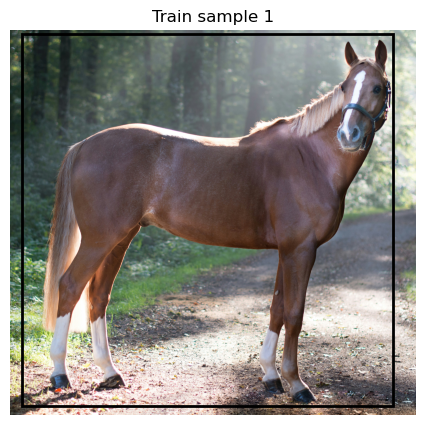

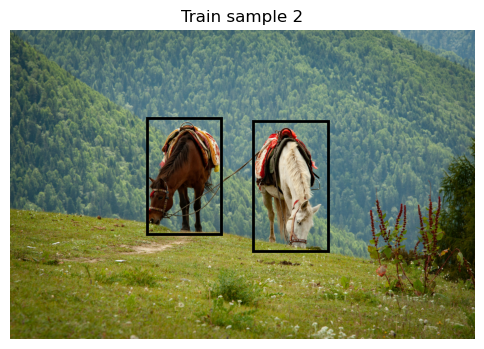

In [26]:
def show_sample(dataset, idx, title="sample"):
    img, target = dataset[idx]
    img_np = img.permute(1, 2, 0).numpy()

    plt.figure(figsize=(6, 5))
    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")

    boxes = target["boxes"]
    if boxes.numel() > 0:
        for b in boxes:
            x1, y1, x2, y2 = b.tolist()
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2))
    plt.show()

# show two random samples from training subset
for k in range(2):
    ridx = random.randint(0, len(train_dataset)-1)
    show_sample(train_dataset, ridx, title=f"Train sample {k+1}")


# Training and evaluation:

In [13]:
def train_one_epoch(model, loader, optimizer, device, epoch=None):
    ### You Code Here ###
    model.train()
    running = 0.0
    n_batches = 0

    pbar = tqdm(loader, desc=f"Train epoch {epoch}" if epoch is not None else "Train", leave=False)
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=float(loss.item()))

    return running / max(1, n_batches)


@torch.no_grad()
def evaluate_map(model, loader, device):
    """mAP evaluation using torchmetrics.
    Returns a dict with keys like 'map', 'map_50', 'mar_100', ...
    """
    ### You Code Here ##
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")

    for images, targets in tqdm(loader, desc="Eval mAP", leave=False):
        images = [img.to(device) for img in images]
        outputs = model(images)

        outputs_cpu = []
        for o in outputs:
            outputs_cpu.append({
                "boxes": o["boxes"].detach().cpu(),
                "scores": o["scores"].detach().cpu(),
                "labels": o["labels"].detach().cpu(),
            })

        targets_cpu = []
        for t in targets:
            targets_cpu.append({
                "boxes": t["boxes"].detach().cpu(),
                "labels": t["labels"].detach().cpu(),
            })

        metric.update(outputs_cpu, targets_cpu)
    return metric.compute()


@torch.no_grad()
def time_inference(model, dataset, device, n_images=100, warmup=10):
    """Average inference time per image (ms)."""
    ### You Code Here ###
    model.eval()
    idxs = [random.randint(0, len(dataset)-1) for _ in range(n_images + warmup)]

    times = []
    for i, idx in enumerate(idxs):
        img, _ = dataset[idx]
        img = img.to(device)

        if device.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        _ = model([img])
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        if i >= warmup:
            times.append((t1 - t0) * 1000.0) 
    return float(np.mean(times)), float(np.std(times))


# Two-stage detector: Faster R-CNN (Region Proposal + classifier)

In [ ]:
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
faster_rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=weights)

in_features = faster_rcnn.roi_heads.box_predictor.cls_score.in_features
faster_rcnn.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Freeze backbone
for p in faster_rcnn.backbone.parameters():
    p.requires_grad = False

faster_rcnn = faster_rcnn.to(device)

# Optimizer
params = [p for p in faster_rcnn.parameters() if p.requires_grad]
optimizer_frcnn = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

print("Faster R-CNN trainable params:", sum(p.numel() for p in params))


Faster R-CNN trainable params: 16401689


In [15]:
num_epochs = 5

frcnn_train_losses = []
frcnn_maps = []

for epoch in range(1, num_epochs + 1):
    loss = train_one_epoch(faster_rcnn, train_loader, optimizer_frcnn, device, epoch=epoch)
    frcnn_train_losses.append(loss)

    metrics = evaluate_map(faster_rcnn, test_loader, device)
    frcnn_maps.append(float(metrics["map"]))

    print(f"[FRCNN] Epoch {epoch}/{num_epochs} | loss={loss:.4f} | mAP={float(metrics['map']):.4f} | mAP50={float(metrics['map_50']):.4f}")

[FRCNN] Epoch 1/5 | loss=0.1663 | mAP=0.7809 | mAP50=0.9795


[FRCNN] Epoch 2/5 | loss=0.0830 | mAP=0.7723 | mAP50=0.9795


[FRCNN] Epoch 3/5 | loss=0.0762 | mAP=0.7855 | mAP50=0.9799


[FRCNN] Epoch 4/5 | loss=0.0690 | mAP=0.7959 | mAP50=0.9802


[FRCNN] Epoch 5/5 | loss=0.0670 | mAP=0.7771 | mAP50=0.9802


# One-stage detector: RetinaNet

In [16]:
weights_rn = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
retinanet = retinanet_resnet50_fpn_v2(weights=weights_rn)

num_anchors = retinanet.head.classification_head.num_anchors
in_channels = retinanet.backbone.out_channels

retinanet.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes,
)

for p in retinanet.backbone.parameters():
    p.requires_grad = False

retinanet = retinanet.to(device)

params_rn = [p for p in retinanet.parameters() if p.requires_grad]
optimizer_rn = torch.optim.SGD(params_rn, lr=0.005, momentum=0.9, weight_decay=0.0005)

print("RetinaNet trainable params:", sum(p.numel() for p in params_rn))

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_v2_coco-5905b1c5.pth" to C:\Users\pauli/.cache\torch\hub\checkpoints\retinanet_resnet50_fpn_v2_coco-5905b1c5.pth
100%|██████████| 146M/146M [01:27<00:00, 1.74MB/s] 


RetinaNet trainable params: 4846134


In [17]:
num_epochs = 5

rn_train_losses = []
rn_maps = []

for epoch in range(1, num_epochs + 1):
    loss = train_one_epoch(retinanet, train_loader, optimizer_rn, device, epoch=epoch)
    rn_train_losses.append(loss)

    metrics = evaluate_map(retinanet, test_loader, device)
    rn_maps.append(float(metrics["map"]))

    print(f"[RETINANET] Epoch {epoch}/{num_epochs} | loss={loss:.4f} | mAP={float(metrics['map']):.4f} | mAP50={float(metrics['map_50']):.4f}")


Eval mAP:  20%|██        | 8/40 [00:15<01:02,  1.94s/it]                  c:\Users\pauli\anaconda3\envs\sensor_fusion\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


[RETINANET] Epoch 1/5 | loss=1.1742 | mAP=0.0152 | mAP50=0.0308


[RETINANET] Epoch 2/5 | loss=1.2245 | mAP=0.0000 | mAP50=0.0000


[RETINANET] Epoch 3/5 | loss=1.1679 | mAP=0.0000 | mAP50=0.0000


[RETINANET] Epoch 4/5 | loss=1.1256 | mAP=0.0000 | mAP50=0.0000


[RETINANET] Epoch 5/5 | loss=1.0744 | mAP=0.0000 | mAP50=0.0000


## val_mAP, val_mAP50, mean_infer_ms for both methods

In [18]:
frcnn_metrics = evaluate_map(faster_rcnn, test_loader, device)
rn_metrics    = evaluate_map(retinanet,  test_loader, device)

frcnn_mean_ms, frcnn_std_ms = time_inference(faster_rcnn, test_dataset, device, n_images=min(50, len(test_dataset)))
rn_mean_ms, rn_std_ms       = time_inference(retinanet,  test_dataset, device, n_images=min(50, len(test_dataset)))

results = pd.DataFrame([
    {
        "model": "Faster R-CNN (two-stage)",
        "mAP": float(frcnn_metrics["map"]),
        "mAP50": float(frcnn_metrics["map_50"]),
        "mean_infer_ms": frcnn_mean_ms,
        "std_infer_ms": frcnn_std_ms,
    },
    {
        "model": "RetinaNet (one-stage)",
        "mAP": float(rn_metrics["map"]),
        "mAP50": float(rn_metrics["map_50"]),
        "mean_infer_ms": rn_mean_ms,
        "std_infer_ms": rn_std_ms,
    },
])

results

,model,mAP,mAP50,mean_infer_ms,std_infer_ms
0,Faster R-CNN (two-stage),0.777051,0.980198,3568.351893,393.859352
1,RetinaNet (one-stage),0.000000,0.000000,2043.530110,312.780672


## Results of two methods for couple of images from test set

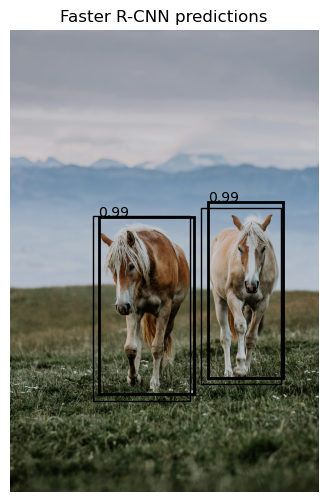

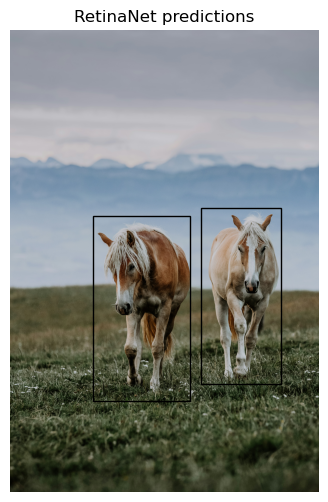

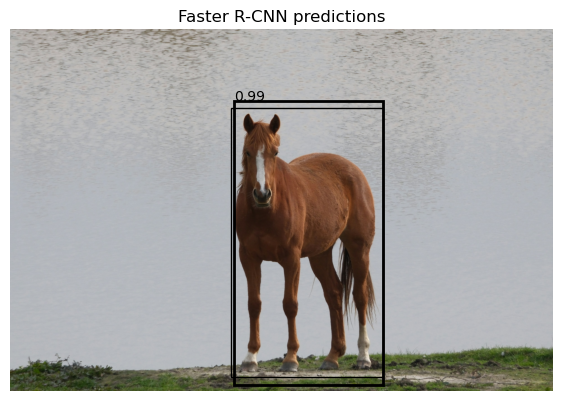

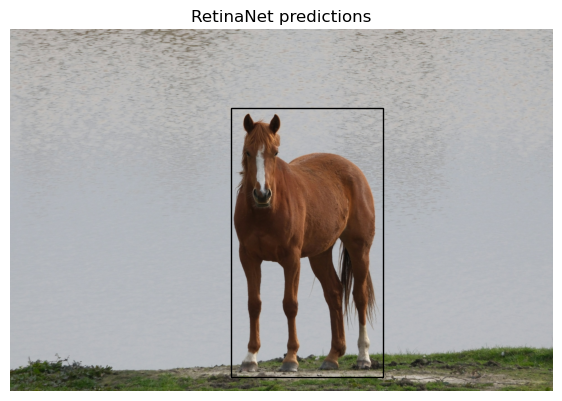

In [20]:
def visualize_predictions(model, dataset, idx, score_thr=0.4, title="pred"):
    model.eval()
    img, target = dataset[idx]
    img_dev = img.to(device)

    with torch.no_grad():
        out = model([img_dev])[0]

    img_np = img.permute(1, 2, 0).numpy()

    plt.figure(figsize=(7, 6))
    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")

    gt_boxes = target["boxes"]
    if gt_boxes.numel() > 0:
        for b in gt_boxes:
            x1, y1, x2, y2 = b.tolist()
            plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=1))

    # Predictions
    keep = out["scores"].detach().cpu().numpy() >= score_thr
    boxes = out["boxes"].detach().cpu().numpy()[keep]
    scores = out["scores"].detach().cpu().numpy()[keep]

    for (x1, y1, x2, y2), s in zip(boxes, scores):
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2))
        plt.text(x1, max(0, y1-5), f"{s:.2f}", fontsize=10)

    plt.show()

# 2 test samples
for k in range(2):
    idx = random.randint(0, len(test_dataset)-1)
    visualize_predictions(faster_rcnn, test_dataset, idx, score_thr=0.4, title="Faster R-CNN predictions")
    visualize_predictions(retinanet,  test_dataset, idx, score_thr=0.4, title="RetinaNet predictions")

## Conclusion

Faster R-CNN achieved strong detection performance, reaching an mAP of approximately 0.78 and mAP50 of 0.98. The model demonstrated stable convergence across training epochs and handled background clutter effectively.

RetinaNet achieved faster inference time but failed to converge under the same training configuration, resulting in near-zero mAP. This suggests that one-stage detectors may be more sensitive to dataset size and hyperparameter settings when trained on small custom datasets.